# Análisis Exploratorio de Indicadores de Suelo y Sociales

Carga y exploración del dataset `INDICADORES_ESTUDIO_GRAL.csv` con el diccionario de datos de `dict_indexes_gral.md`.

In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'src' else cwd
DATA_DIR = root / 'data'
DOC_DIR = root / 'doc'

In [2]:
df = pd.read_csv(DATA_DIR / 'INDICADORES_ESTUDIO_GRAL.csv')

rename_map = {
    'IND 1.1': 'WEI',
    'IND 1.2': 'TCMA',
    'IND 1.3': 'Porc_poblacion_en_urbana',
    'IND 1.4': 'Densidad_urbana',
    'IND 2.1': 'Ind_POT',
    'IND 2.2': 'Ind_eficiencia_recaudo',
    'IND 2.3': 'Ingresos_tributarios_percap',
    'IND 2.4': 'Percepcion_corrupcion',
    'IND 2.5': 'Percepcion_verde',
    'IND 3.1': 'Porc_pobreza_monetaria',
    'IND 3.2': 'Porc_pobreza_extrema',
    'IND 3.3': 'Porc_pobreza_multi',
    'IND 3.4': 'GINI',
    'IND 3.5': 'Porc_informal',
    'IND 4.1': 'Porc_deficit_vivienda_cuali',
    'IND 4.2': 'Porc_deficit_vivienda_cuanti',
    'IND 4.3': 'Porc_contaminacion_aire',
    'IND 4.4': 'Porc_contaminacion_agua',
}
df = df.rename(columns=rename_map)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print()
df.head(25).to_string()

Shape: (23, 30)
Columns: ['SUBREGIÓN', 'MUNICIPIO', 'AREA KM2', 'AREA KM2 URBANA', 'POBLACION ESTIMADA 2021/RURAL', 'POBLACION ESTIMADA 2021/URBANA', 'TOTAL POBLACIÓN', 'WEI', 'TCMA', 'Porc_poblacion_en_urbana', 'Densidad_urbana', 'IND 2.1 TIPO', 'Ind_POT', 'AÑOS REVISION', 'AÑO ULTIMA REVISION', 'IND 2.1 REVISION', 'IND 2.1 ZONAS AMB', 'Ind_eficiencia_recaudo', 'Ingresos_tributarios_percap', 'Percepcion_corrupcion', 'Percepcion_verde', 'Porc_pobreza_monetaria', 'Porc_pobreza_extrema', 'Porc_pobreza_multi', 'GINI', 'Porc_informal', 'Porc_deficit_vivienda_cuali', 'Porc_deficit_vivienda_cuanti', 'Porc_contaminacion_aire', 'Porc_contaminacion_agua']



'              SUBREGIÓN     MUNICIPIO     AREA KM2 AREA KM2 URBANA  POBLACION ESTIMADA 2021/RURAL  POBLACION ESTIMADA 2021/URBANA  TOTAL POBLACIÓN     WEI    TCMA Porc_poblacion_en_urbana Densidad_urbana IND 2.1 TIPO Ind_POT AÑOS REVISION  AÑO ULTIMA REVISION  IND 2.1 REVISION IND 2.1 ZONAS AMB Ind_eficiencia_recaudo Ingresos_tributarios_percap Percepcion_corrupcion Percepcion_verde Porc_pobreza_monetaria Porc_pobreza_extrema Porc_pobreza_multi    GINI Porc_informal Porc_deficit_vivienda_cuali Porc_deficit_vivienda_cuanti Porc_contaminacion_aire Porc_contaminacion_agua\n0   Sabana noroccidente      El Rosal     87,12009           5,403                         2494.0                         22051.0          24545.0  0,1494  1,7158                   88,40%       461,59541          EOT    0,75         -6,00               2015.0               1.0              0,50            62,04/47,12                     367.868                33,24%           13,89%                 29,97%              

In [3]:
print(df.dtypes)
print()
print('Rows:', len(df))
print('SUBREGIÓN values:', df['SUBREGIÓN'].unique())

SUBREGIÓN                          object
MUNICIPIO                          object
AREA KM2                           object
AREA KM2 URBANA                    object
POBLACION ESTIMADA 2021/RURAL     float64
POBLACION ESTIMADA 2021/URBANA    float64
TOTAL POBLACIÓN                   float64
WEI                                object
TCMA                               object
Porc_poblacion_en_urbana           object
Densidad_urbana                    object
IND 2.1 TIPO                       object
Ind_POT                            object
AÑOS REVISION                      object
AÑO ULTIMA REVISION               float64
IND 2.1 REVISION                  float64
IND 2.1 ZONAS AMB                  object
Ind_eficiencia_recaudo             object
Ingresos_tributarios_percap        object
Percepcion_corrupcion              object
Percepcion_verde                   object
Porc_pobreza_monetaria             object
Porc_pobreza_extrema               object
Porc_pobreza_multi                

In [4]:
def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    s = s.replace('%', '')
    s = s.replace('.', '')
    s = s.replace(',', '.')
    try:
        return float(s)
    except ValueError:
        return np.nan

soil_cols = ['WEI', 'TCMA', 'Porc_poblacion_en_urbana', 'Densidad_urbana']
social_cols = ['Ingresos_tributarios_percap', 'Percepcion_corrupcion', 'Percepcion_verde',
               'Porc_pobreza_monetaria', 'Porc_pobreza_extrema', 'Porc_pobreza_multi', 'GINI', 'Porc_informal',
               'Porc_deficit_vivienda_cuali', 'Porc_deficit_vivienda_cuanti', 'Porc_contaminacion_aire', 'Porc_contaminacion_agua']

all_index_cols = soil_cols + social_cols

for col in all_index_cols:
    df[col] = df[col].apply(clean_numeric)

df_num = df.dropna(subset=['MUNICIPIO'] + all_index_cols).copy()
df_num = df_num[~df_num['MUNICIPIO'].str.contains('TOTALES', case=False, na=False)]
df_num = df_num[~df_num['MUNICIPIO'].str.strip().isin(['', 'nan'])]

print(f'Rows after cleaning: {len(df_num)}')
print(f'Soil cols (numeric): {df_num[soil_cols].dtypes.to_dict()}')
print(f'Social cols (numeric): {df_num[social_cols].dtypes.to_dict()}')

Rows after cleaning: 20
Soil cols (numeric): {'WEI': dtype('float64'), 'TCMA': dtype('float64'), 'Porc_poblacion_en_urbana': dtype('float64'), 'Densidad_urbana': dtype('float64')}
Social cols (numeric): {'Ingresos_tributarios_percap': dtype('float64'), 'Percepcion_corrupcion': dtype('float64'), 'Percepcion_verde': dtype('float64'), 'Porc_pobreza_monetaria': dtype('float64'), 'Porc_pobreza_extrema': dtype('float64'), 'Porc_pobreza_multi': dtype('float64'), 'GINI': dtype('float64'), 'Porc_informal': dtype('float64'), 'Porc_deficit_vivienda_cuali': dtype('float64'), 'Porc_deficit_vivienda_cuanti': dtype('float64'), 'Porc_contaminacion_aire': dtype('float64'), 'Porc_contaminacion_agua': dtype('float64')}


In [5]:
print('Subregion counts:')
print(df_num['SUBREGIÓN'].value_counts().to_string())
print()
print('Basic stats for soil indexes:')
df_num[soil_cols].describe().round(4).to_string()
print()
print('Basic stats for social indexes:')
df_num[social_cols].describe().round(4).to_string()

Subregion counts:
SUBREGIÓN
Sabana Centro          6
Sabana suroccidente    5
Sabana noroccidente    3
Sabana Norte           3
Soacha - Sibaté        2
Guavio                 1

Basic stats for soil indexes:

Basic stats for social indexes:


'       Ingresos_tributarios_percap  Percepcion_corrupcion  Percepcion_verde  Porc_pobreza_monetaria  Porc_pobreza_extrema  Porc_pobreza_multi     GINI  Porc_informal  Porc_deficit_vivienda_cuali  Porc_deficit_vivienda_cuanti  Porc_contaminacion_aire  Porc_contaminacion_agua\ncount                 2.000000e+01                20.0000           20.0000                 20.0000               20.0000             20.0000  20.0000        20.0000                      20.0000                       20.0000                  20.0000                  20.0000\nmean                  1.003776e+06                30.9480           14.6710                 18.8645                5.9530              5.8225   0.4361        38.7135                      13.8395                        1.4865                  12.5095                   4.0890\nstd                   8.866163e+05                10.6633            8.6201                  6.7065                2.6956              2.4580   0.0589         9.1156      

In [10]:
subregion_palette = sns.color_palette('husl', n_colors=df_num['SUBREGIÓN'].nunique())
subregion_map = dict(zip(df_num['SUBREGIÓN'].unique(), subregion_palette))

n_social = len(social_cols)

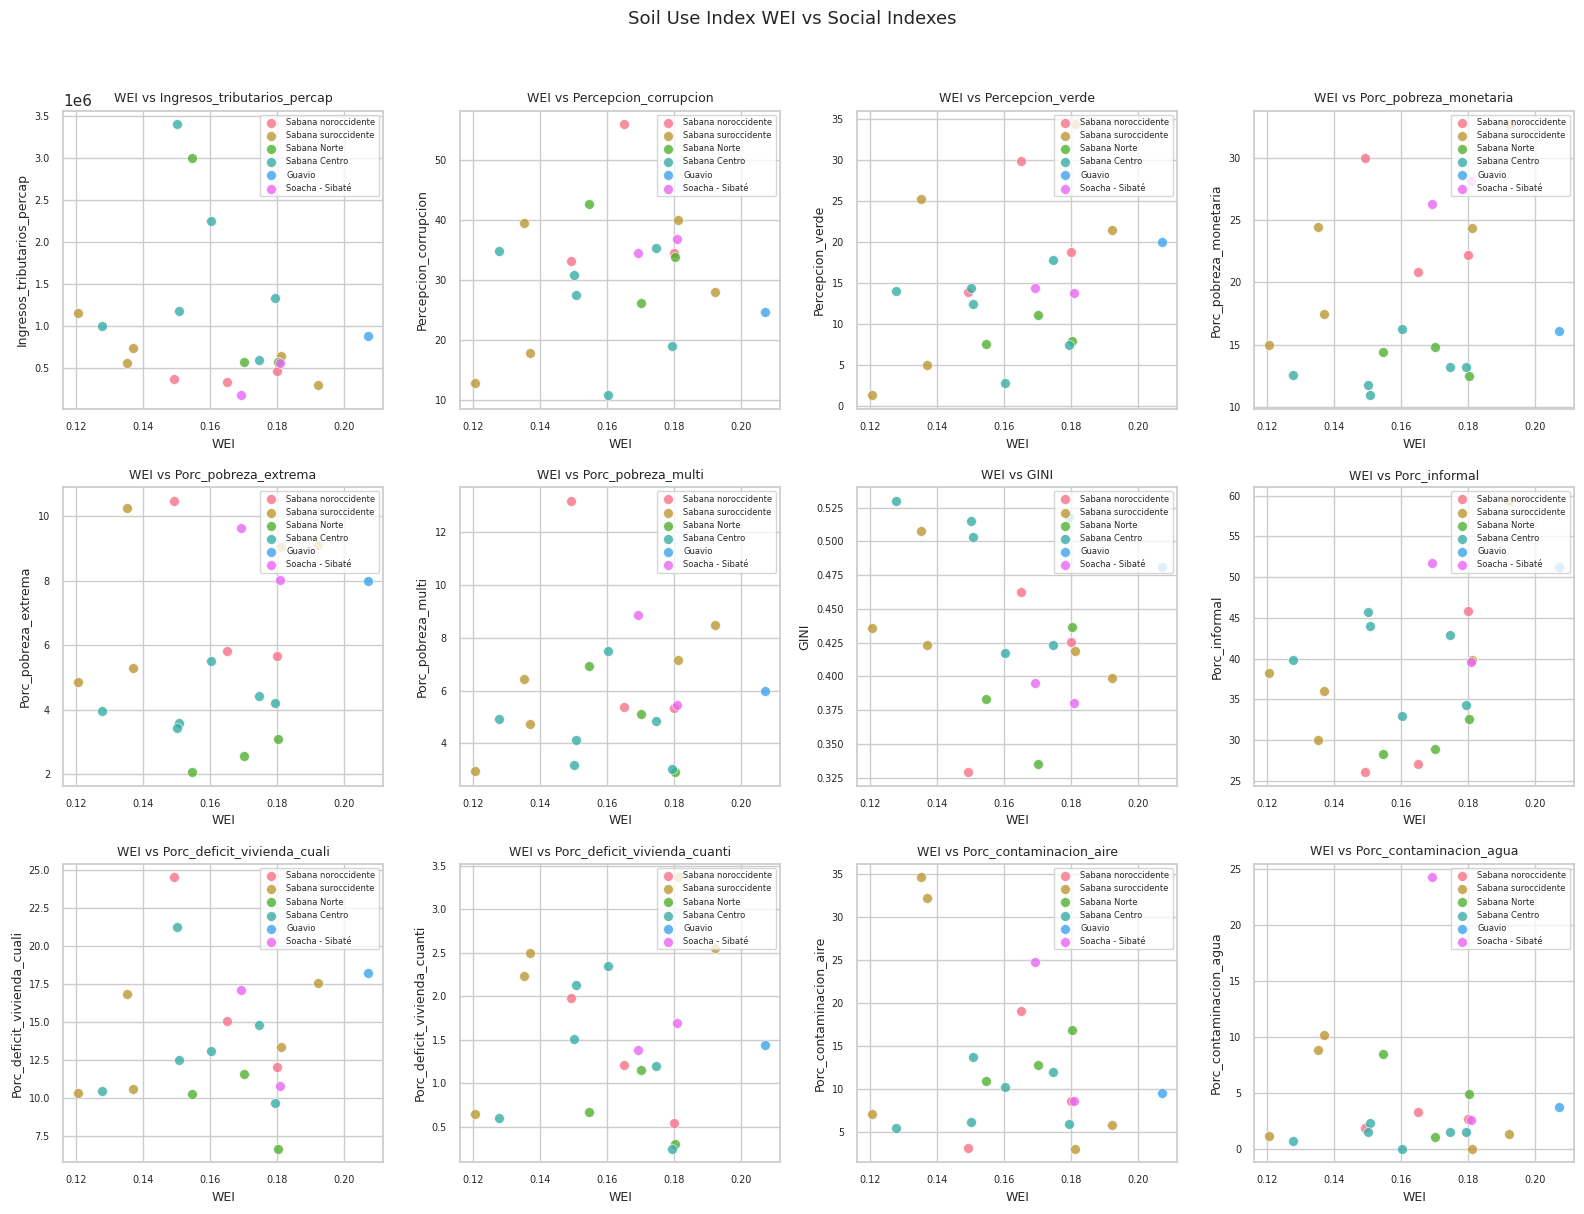

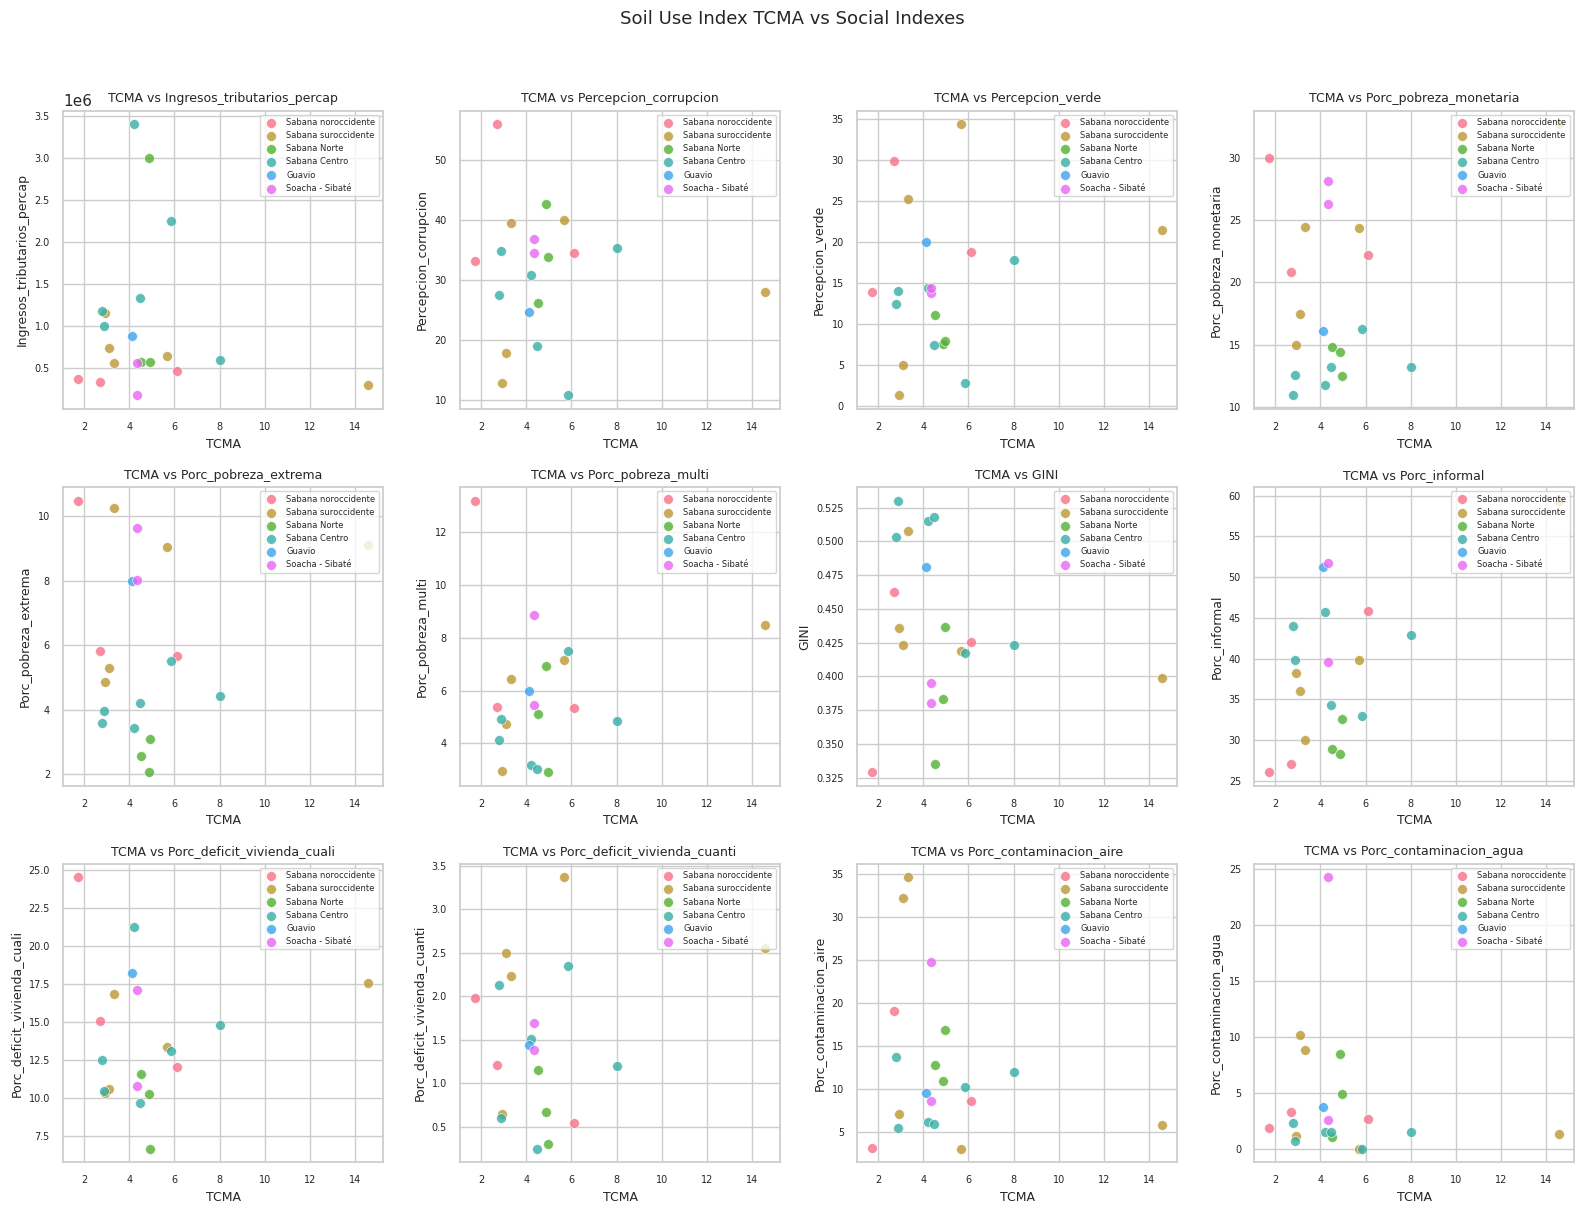

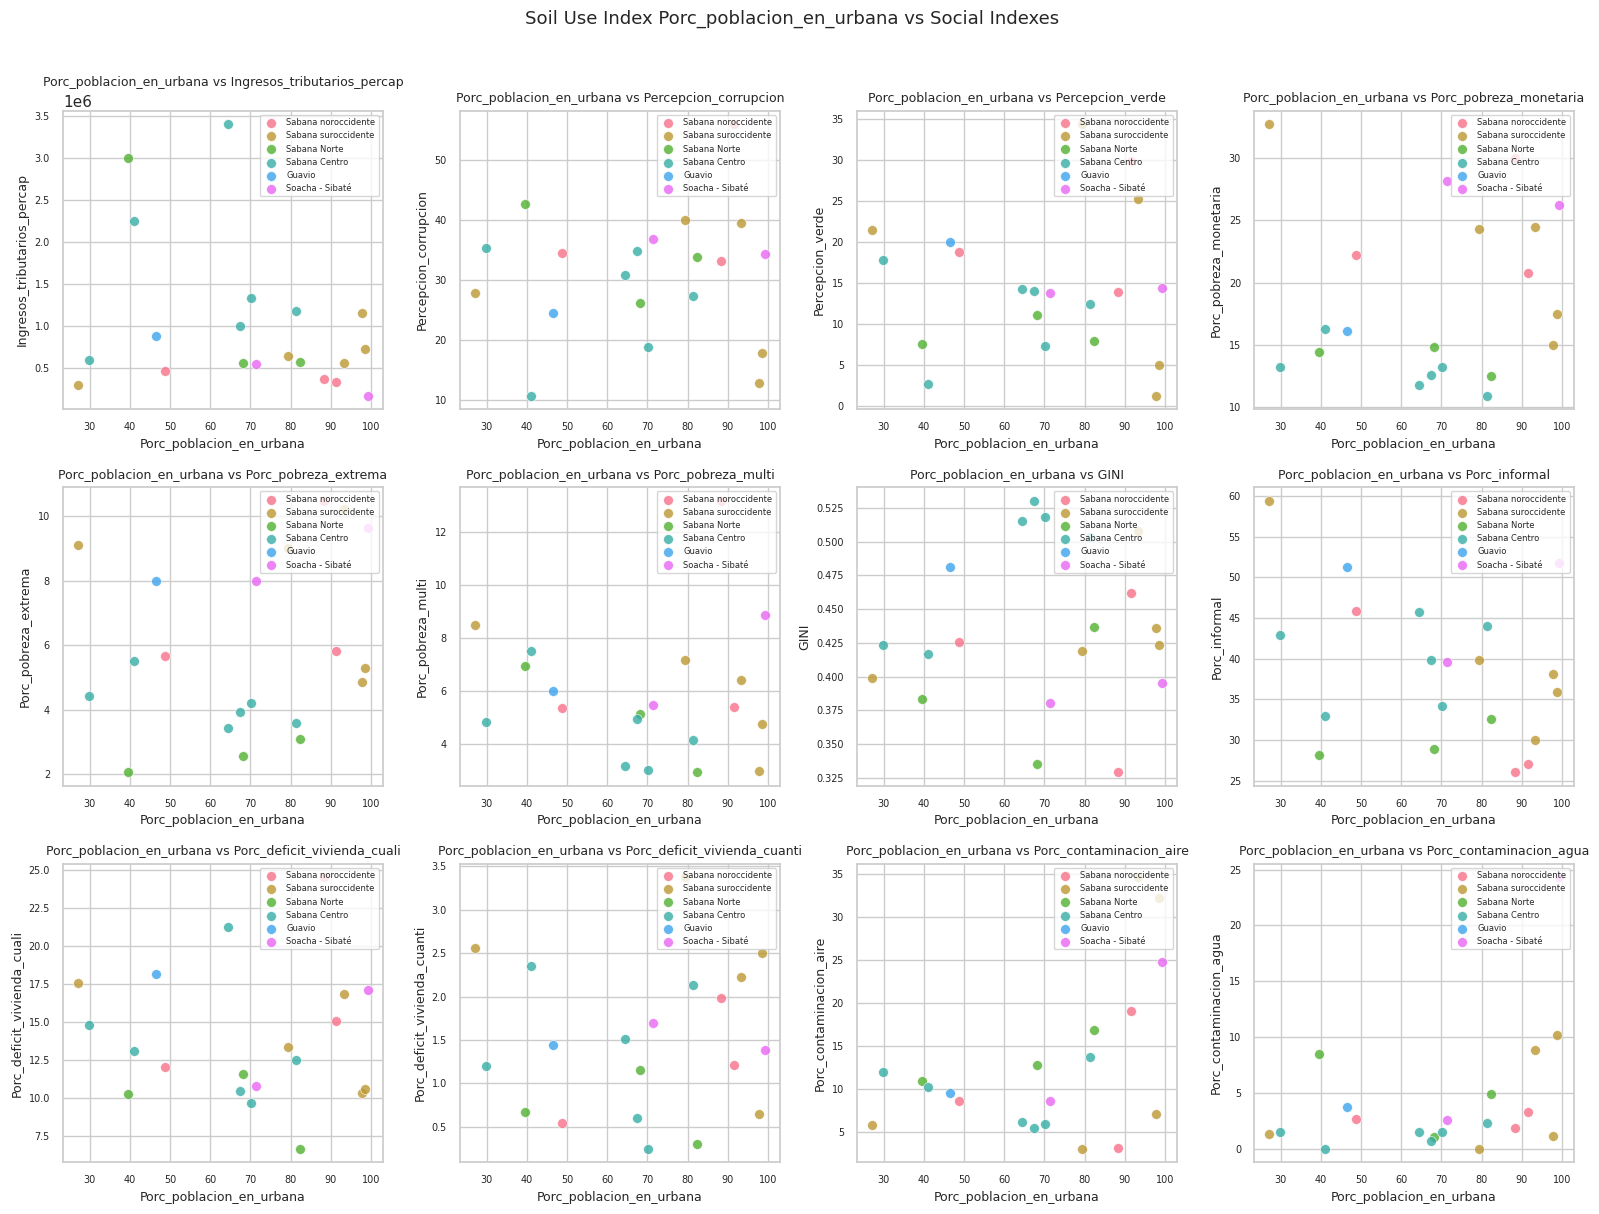

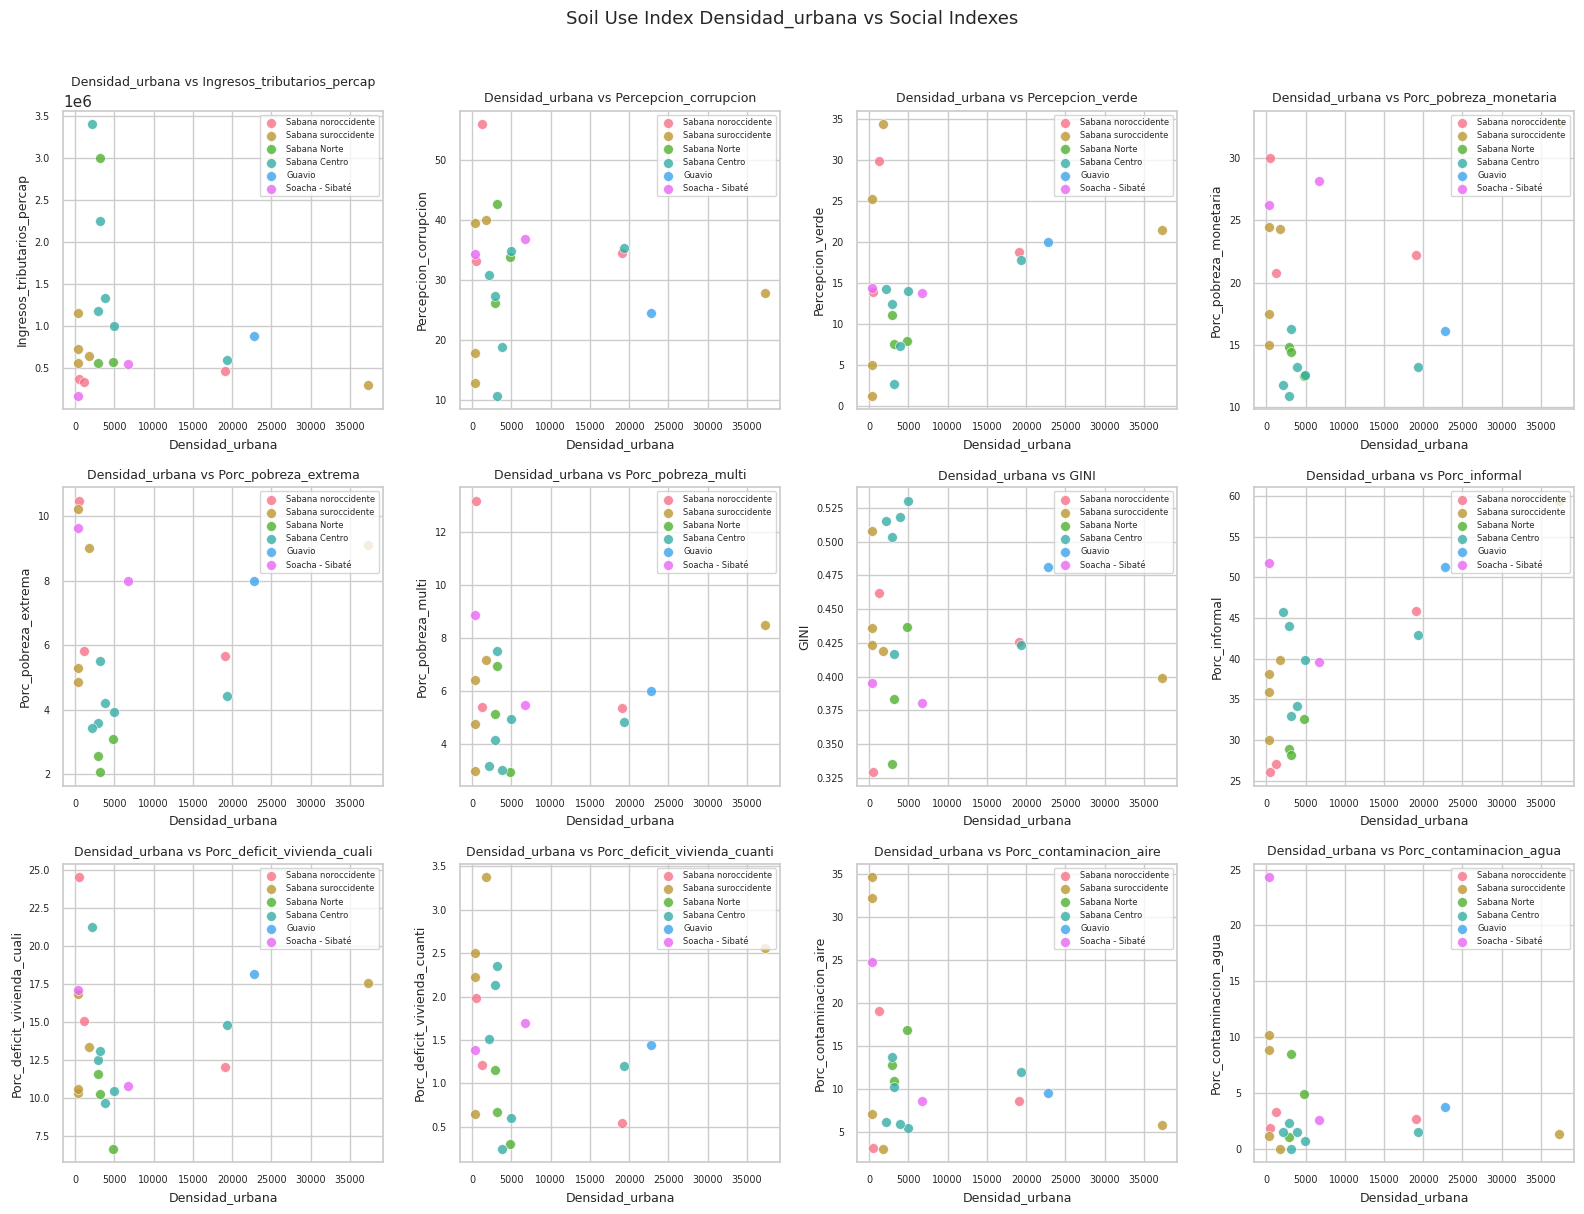

In [9]:
for soil_col in soil_cols:
    fig, axes = plt.subplots(3, 4, figsize=(16, 12), squeeze=False)
    axes = axes.flatten()
    
    for j, social_col in enumerate(social_cols):
        ax = axes[j]
        for subreg in df_num['SUBREGIÓN'].unique():
            mask = df_num['SUBREGIÓN'] == subreg
            ax.scatter(df_num.loc[mask, soil_col], df_num.loc[mask, social_col],
                       label=subreg, color=subregion_map[subreg], alpha=0.8, s=50, edgecolors='white', linewidth=0.5)
        ax.set_xlabel(soil_col, fontsize=9)
        ax.set_ylabel(social_col, fontsize=9)
        ax.tick_params(labelsize=7)
        ax.set_title(f'{soil_col} vs {social_col}', fontsize=9)
        ax.legend(fontsize=6, loc='upper right')
    
    # Hide unused subplots
    for j in range(n_social, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'Soil Use Index {soil_col} vs Social Indexes', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

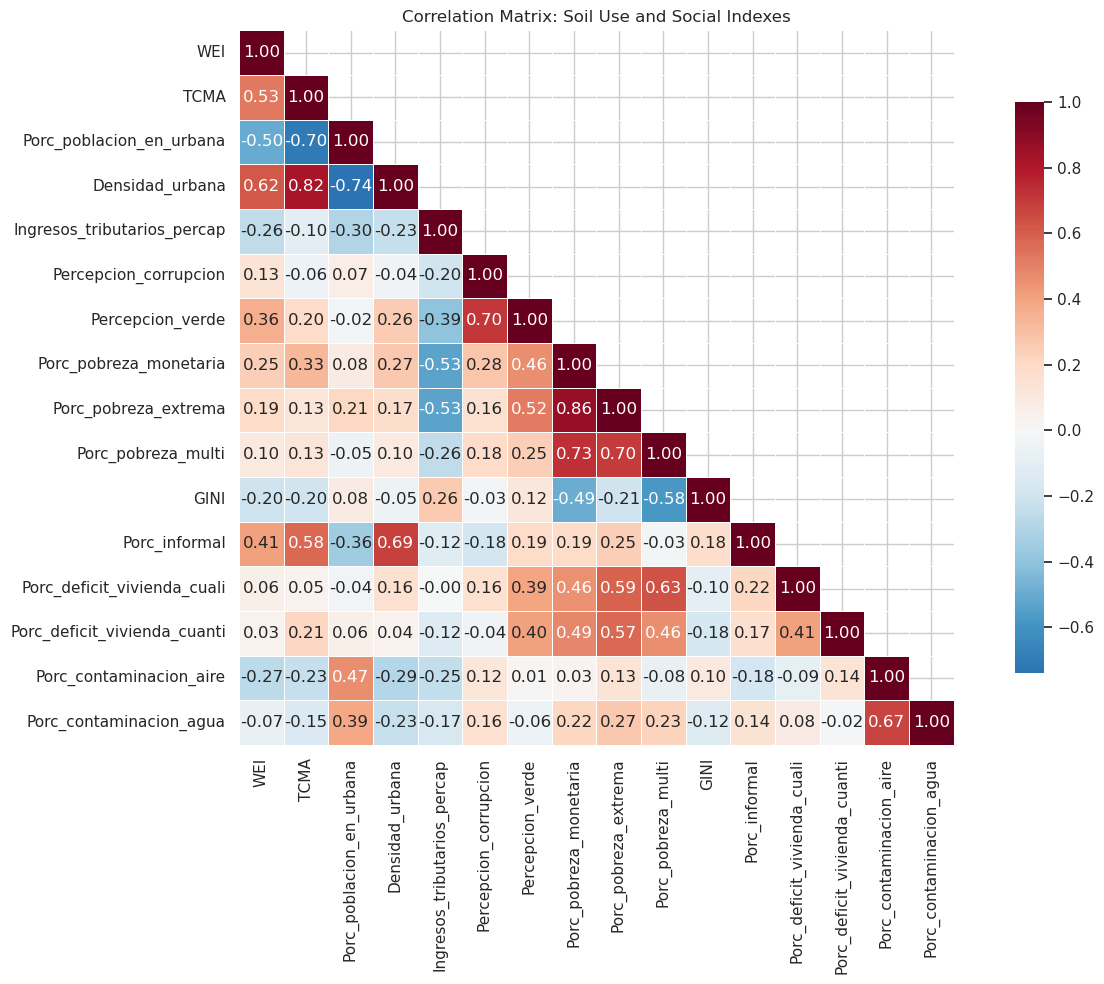

In [ ]:
corr_cols = soil_cols + social_cols
corr_matrix = df_num[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Soil Use and Social Indexes', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
df_num.to_csv(EXPORT_DIR / 'INDICADORES_ESTUDIO_GRAL_clean.csv', index=False)
print(f'Saved cleaned data')

Saved cleaned data
